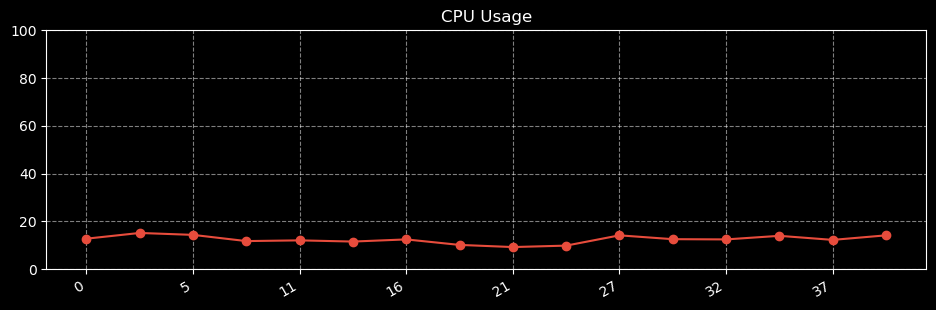

In [13]:
import tkinter as tk
from tkinter import ttk, messagebox
import psutil
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
import time

plt.style.use('dark_background')

class SystemMonitorApp:
    def __init__(self, root):
        self.root = root
        self.root.title("System Monitor")
        self.root.geometry("1000x800")
        self.root.configure(bg='#2c3e50')

        self.timestamps = []
        self.cpu_data = []
        self.memory_data = []
        self.disk_data = []
        self.network_sent_speed = []
        self.network_received_speed = []

        self.start_time = None
        self.last_net_io = psutil.net_io_counters()

        self.graph_option = tk.StringVar(value="CPU Usage")

        self.setup_ui()
        self.init_plot()
        self.update_data()
        self.root.after(8000, self.cleanup_old_data)

    def setup_ui(self):
        style = ttk.Style()
        style.theme_use("clam")
        style.configure("TFrame", background="#34495e")
        style.configure("TLabel", background="#34495e", foreground="white", font=("Segoe UI", 10, "bold"))
        style.configure("Treeview", background="#2c3e50", foreground="white", fieldbackground="#2c3e50")
        style.map('Treeview', background=[('selected', '#2980b9')])

        main_frame = ttk.Frame(self.root, padding="12 12 12 12")
        main_frame.pack(fill=tk.BOTH, expand=True, padx=15, pady=10)

        info_frame = ttk.Frame(main_frame)
        info_frame.pack(fill=tk.X)

        self.cpu_label = ttk.Label(info_frame, text="CPU Usage: 0.0%")
        self.cpu_label.pack(anchor=tk.W)

        self.memory_label = ttk.Label(info_frame, text="Memory Usage: 0.0%")
        self.memory_label.pack(anchor=tk.W)

        self.disk_label = ttk.Label(info_frame, text="Disk Usage: 0.0%")
        self.disk_label.pack(anchor=tk.W)

        self.network_label = ttk.Label(info_frame, text="Network: ↑ 0.00 MB/s, ↓ 0.00 MB/s")
        self.network_label.pack(anchor=tk.W)

        dropdown_frame = ttk.Frame(main_frame)
        dropdown_frame.pack(pady=5, anchor=tk.W)

        ttk.Label(dropdown_frame, text="Select Graph:").pack(side=tk.LEFT)
        options = ["CPU Usage", "Memory Usage", "Disk Usage", "Network Speed"]
        ttk.OptionMenu(dropdown_frame, self.graph_option, options[0], *options, command=self.update_graphs).pack(side=tk.LEFT, padx=5)

        self.fig, self.ax = plt.subplots(figsize=(9, 3), dpi=100)
        self.canvas = FigureCanvasTkAgg(self.fig, master=main_frame)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True, pady=5)

        self.process_tree = ttk.Treeview(main_frame, columns=("PID", "Name", "CPU", "Memory"), show="headings", height=10)
        for col in ("PID", "Name", "CPU", "Memory"):
            self.process_tree.heading(col, text=col)
            self.process_tree.column(col, anchor=tk.CENTER)

        self.process_tree.pack(fill=tk.BOTH, expand=True, pady=10)

        terminate_btn = ttk.Button(main_frame, text="Terminate Selected Process", command=self.terminate_process)
        terminate_btn.pack()

    def init_plot(self):
        self.ax.set_title("System Metric")
        self.ax.set_ylabel("Value")
        self.ax.grid(True, linestyle="--", alpha=0.5)
        self.fig.tight_layout()
        self.canvas.draw()

    def update_data(self):
        if self.start_time is None:
            self.start_time = time.time()

        elapsed_time = int(time.time() - self.start_time)
        self.timestamps.append(str(elapsed_time))

        cpu_usage = psutil.cpu_percent()
        memory_usage = psutil.virtual_memory().percent
        disk_usage = psutil.disk_usage('/').percent
        current_net_io = psutil.net_io_counters()

        sent_speed = (current_net_io.bytes_sent - self.last_net_io.bytes_sent) / (1024 * 1024)
        recv_speed = (current_net_io.bytes_recv - self.last_net_io.bytes_recv) / (1024 * 1024)
        self.last_net_io = current_net_io

        self.cpu_data.append(cpu_usage)
        self.memory_data.append(memory_usage)
        self.disk_data.append(disk_usage)
        self.network_sent_speed.append(sent_speed)
        self.network_received_speed.append(recv_speed)

        self.cpu_label.config(text=f"CPU Usage: {cpu_usage:.1f}%")
        self.memory_label.config(text=f"Memory Usage: {memory_usage:.1f}%")
        self.disk_label.config(text=f"Disk Usage: {disk_usage:.1f}%")
        self.network_label.config(text=f"Network: ↑ {sent_speed:.2f} MB/s, ↓ {recv_speed:.2f} MB/s")

        self.update_graphs()
        self.update_process_list()

        self.root.after(1500, self.update_data)

    def cleanup_old_data(self):
        if len(self.timestamps) > 15:
            self.timestamps.pop(0)
            self.cpu_data.pop(0)
            self.memory_data.pop(0)
            self.disk_data.pop(0)
            self.network_sent_speed.pop(0)
            self.network_received_speed.pop(0)
        self.root.after(8000, self.cleanup_old_data)

    def update_graphs(self, *_):
        self.ax.clear()
        selected = self.graph_option.get()
        time_labels = self.timestamps
        if not time_labels:
            return

        show_every = max(1, len(time_labels) // 8)
        x_ticks = range(0, len(time_labels), show_every)
        x_labels = [time_labels[i] for i in x_ticks]

        if selected == "CPU Usage":
            self.ax.plot(time_labels, self.cpu_data, color="#e74c3c", marker='o')
            self.ax.set_title("CPU Usage")
            self.ax.set_ylim(0, 100)

        elif selected == "Memory Usage":
            self.ax.plot(time_labels, self.memory_data, color="#3498db", marker='o')
            self.ax.set_title("Memory Usage")
            self.ax.set_ylim(0, 100)

        elif selected == "Disk Usage":
            self.ax.plot(time_labels, self.disk_data, color="#2ecc71", marker='o')
            self.ax.set_title("Disk Usage")
            self.ax.set_ylim(0, 100)

        elif selected == "Network Speed":
            self.ax.plot(time_labels, self.network_sent_speed, 'o-', color="#9B59B6", label="Sent (MB/s)")
            self.ax.plot(time_labels, self.network_received_speed, 'o-', color="#F39C12", label="Received (MB/s)")
            self.ax.set_title("Network Speed")
            max_val = max(max(self.network_sent_speed, default=1), max(self.network_received_speed, default=1))
            self.ax.set_ylim(0, max_val * 1.2)
            self.ax.legend(loc='upper left', fontsize=8)

        self.ax.set_xticks(x_ticks)
        self.ax.set_xticklabels(x_labels, rotation=30, ha='right')
        self.ax.grid(True, linestyle="--", alpha=0.5)
        self.fig.tight_layout()
        self.canvas.draw()

    def update_process_list(self):
        for item in self.process_tree.get_children():
            self.process_tree.delete(item)

        processes = []
        for proc in psutil.process_iter(['pid', 'name', 'cpu_percent', 'memory_percent']):
            try:
                processes.append(proc.info)
            except psutil.NoSuchProcess:
                continue

        top = sorted(processes, key=lambda x: x['cpu_percent'], reverse=True)[:10]

        for proc in top:
            self.process_tree.insert("", tk.END, values=(
                proc['pid'],
                proc['name'][:20],
                f"{proc['cpu_percent']:.1f}",
                f"{proc['memory_percent']:.1f}"
            ))

    def terminate_process(self):
        selected_item = self.process_tree.focus()
        if not selected_item:
            messagebox.showwarning("No selection", "Please select a process to terminate.")
            return

        values = self.process_tree.item(selected_item, 'values')
        pid = int(values[0])
        try:
            proc = psutil.Process(pid)
            proc.terminate()
            proc.wait(timeout=3)
            messagebox.showinfo("Success", f"Process {pid} terminated successfully.")
        except Exception as e:
            messagebox.showerror("Error", f"Failed to terminate process {pid}.\n{str(e)}")


if __name__ == "__main__":
    root = tk.Tk()
    app = SystemMonitorApp(root)
    root.mainloop()


In [ ]:








































.









































